In [132]:

import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [133]:
df=pd.read_csv("smartcart_customers.csv")

In [134]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

Data Preprocessing


1) Handel Missing Values

In [135]:
df["Income"]=df["Income"].fillna(df["Income"].median())

2.Feature Engineering

In [136]:
# Instead of year of birth, Age will be a better parameter for Smart Card, therefore creating a new pararmeter "Age"
# Age
df["Age"] = 2026-df["Year_Birth"]

In [137]:
# clustering algorithms cannot interpret date values in a good way, therefore convering it to some numerical format 
# Customer Joining Date 
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date-df["Dt_Customer"]).dt.days

In [139]:
# There are different products(like gold, wine etc), so instead of using them individually, we will be combining them as Total Spending  
# Spending 

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [140]:
# children

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [141]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [142]:
# Education

df["Education"] =  df["Education"].replace({
    "Basic" : "Undergraduate", "2n Cycle" : "Undergraduate", 
    "Graduation" : "Graduate" , 
    "Master" : "Postgraduate" , "PhD" : "Postgraduate"
})
# Instead of 5 categories we will be dividing Education into 3 categories, ie. Undergraduate, Graduate, Postgraduate

In [143]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [144]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [145]:
# Marital Status 

df["Living_With"] =  df["Marital_Status"].replace({
    "Married" : "Partner", "Together" : "Partner", 
    "Single" : "Alone" , "Divorced" : "Alone" , "Widow" : "Alone" , "Absurd" : "Alone" , "YOLO" : "Alone"
    
})

In [146]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

4)Drop Columns

In [147]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols 

df_cleaned = df.drop(columns = cols_to_drop)

In [148]:
df_cleaned.shape

(2240, 15)

In [149]:

df.shape

(2240, 27)

In [150]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


5)Outliers

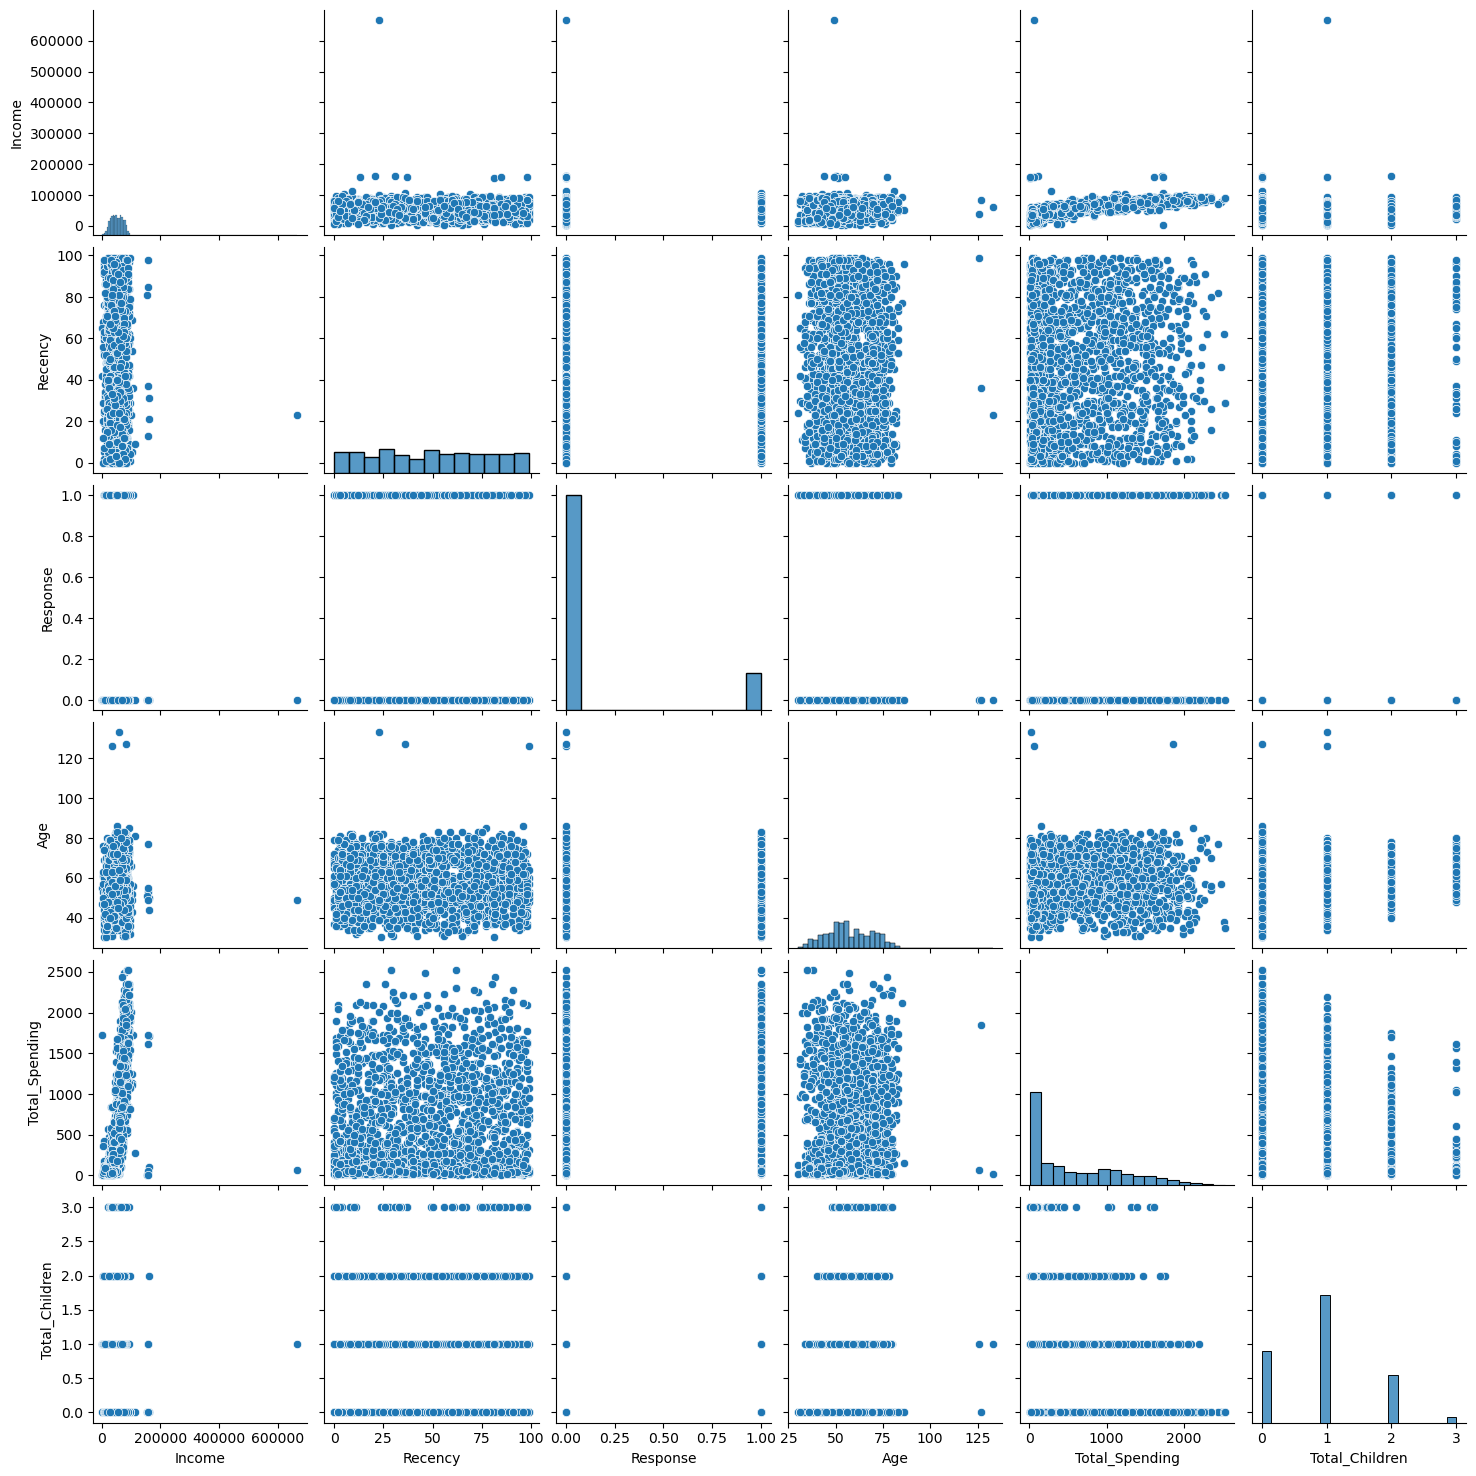

In [151]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# Relative plots of some features - Pair plots 
sns.pairplot(df_cleaned[cols])

In [152]:
# Remove Outliers 
# in "Age" - 120 is an outlier so we need to remove it 
# similarly in income an outlier is present ie. > 600_000, so we need to remove them 
df_cleaned = df_cleaned[df_cleaned["Age"]<90]
df_cleaned = df_cleaned[df_cleaned["Income"]<600_000]

In [153]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

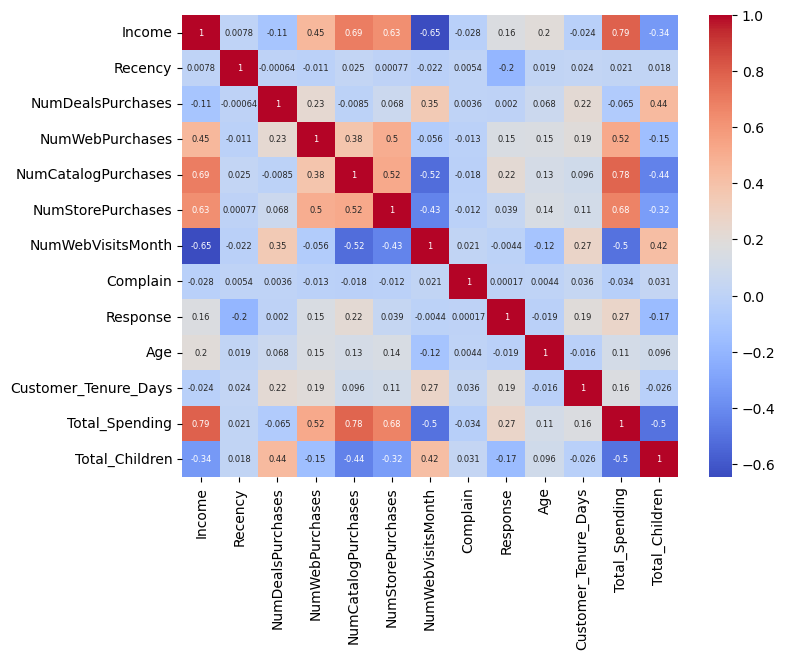

In [154]:
plt.figure(figsize = (8,6))
sns.heatmap(
    corr, 
    annot = True, 
    annot_kws = {"size":6},
    cmap = "coolwarm"
)

#7)Encoding

In [155]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [156]:
from sklearn.preprocessing import OneHotEncoder

In [157]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [158]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns =ohe.get_feature_names_out(cat_cols), index = df_cleaned.index)

In [159]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [160]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols), enc_df], axis = 1 )

In [161]:
df_encoded.shape

(2236, 18)

In [162]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


Scaling

In [169]:
from sklearn.preprocessing import StandardScaler

In [170]:
X = df_encoded

In [171]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [173]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]])

Visualize

In [174]:
X_scaled.shape

(2236, 18)

In [175]:
from sklearn.decomposition import PCA

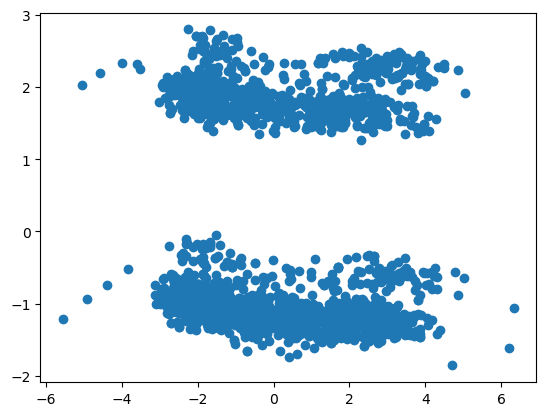

In [176]:
#PCa 2d
pca = PCA(n_components = 2)

X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0],X_pca[:,1])

In [177]:
pca.explained_variance_ratio_  

array([0.23163158, 0.11385454])

In [178]:
#PCa 3d
pca = PCA(n_components = 3)

X_pca = pca.fit_transform(X_scaled)



In [179]:
pca.explained_variance_ratio_  

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D Projection')

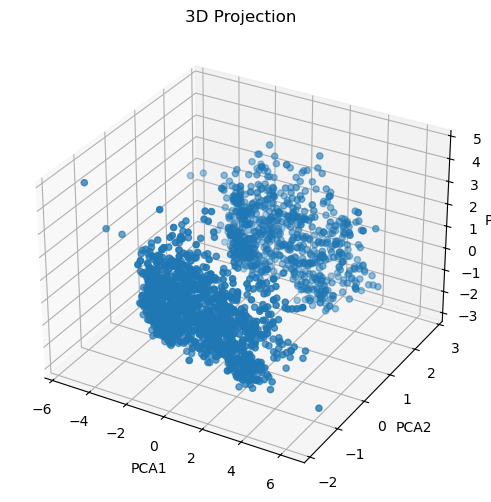

In [180]:
fig = plt.figure(figsize= (8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")

ax.set_title("3D Projection")


Analyse K values


1)Elbow Method

In [183]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss =[]
for k in range(1,11):
    kmeans =KMeans(n_clusters =k,random_state =42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [184]:
knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k= knee.elbow

In [185]:
print("best k =",optimal_k)

best k = 4


#Plot
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")

2)Silhouette score

Text(0, 0.5, 'Silhouette Score')

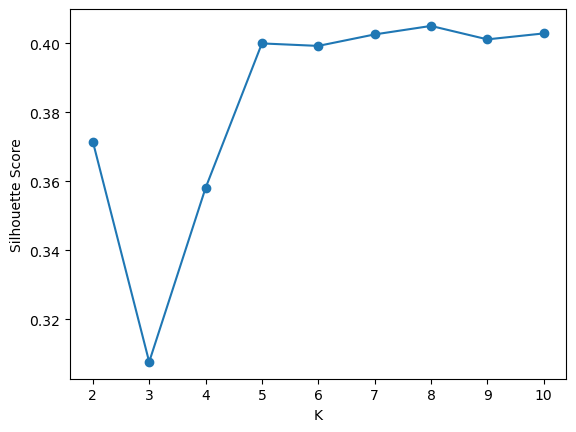

In [190]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

plt.plot(range(2,11), scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")

Text(0, 0.5, 'Silohuette Score')

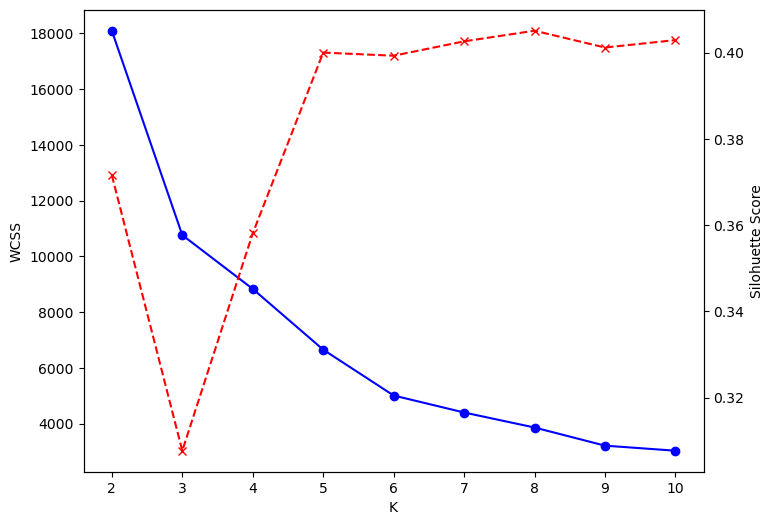

In [191]:
# conbined plot
k_range = range(2,11)

fig, ax1 = plt.subplots(figsize = (8, 6))
ax1.plot(k_range, wcss[:len(k_range)], marker ="o", color="blue")

ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("Silohuette Score")


Clustering

In [192]:
    #Kmeans
kmeans = KMeans(n_clusters = 4 , random_state = 42)
labels_kmaens = kmeans.fit_predict(X_pca)

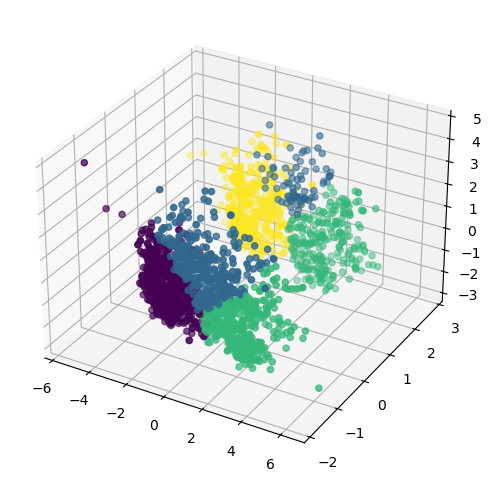

In [193]:
fig = plt.figure(figsize= (8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_kmaens)

In [194]:
# Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering

In [195]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage = "ward")
labels_agg = agg_clf.fit_predict(X_pca)

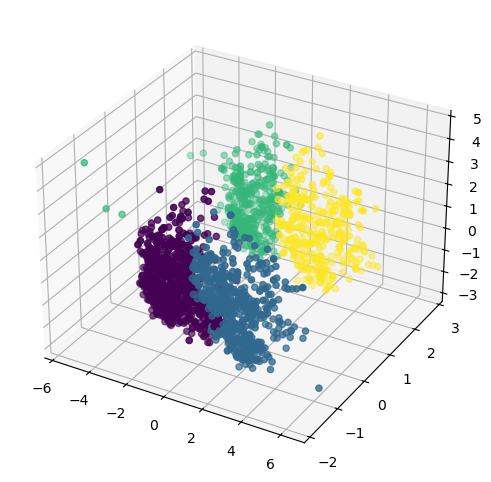

In [196]:
fig = plt.figure(figsize= (8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=labels_agg)

Characterisation of Clusters

In [197]:
X["cluster"]= labels_agg

In [198]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

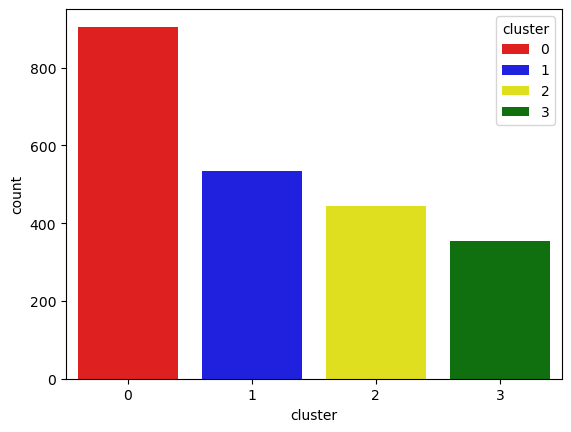

In [199]:
pal = ["red", "blue", "yellow", "green"]
sns.countplot(x=X["cluster"], palette = pal, hue=X["cluster"] )

<Axes: xlabel='Total_Spending', ylabel='Income'>

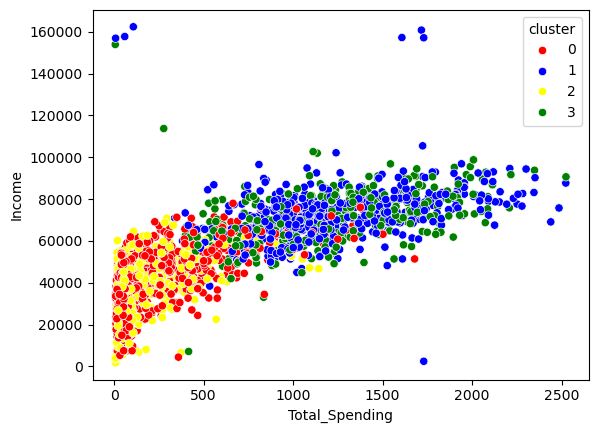

In [200]:
# Income & Spending Patterns

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette= pal)

In [201]:
# Cluster Summary
cluster_summary= X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         